# DVCS training and holdout overview

This notebook reads small training JSON records plus final holdout PNGs directly from project tar archives; it does not extract the multi-GB archives or load PyTorch checkpoints.

Negative log density (NLL) is the training objective, so **lower is better**. A falling training curve paired with a rising validation curve indicates overfitting. The outer test set was not used for training, early stopping, or ensemble selection.

In [1]:
from pathlib import Path
from IPython.display import Markdown, display
import io
import json
import os
import re
import tarfile

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

DEFAULT_ARCHIVE = Path(
    "/w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/results/swif2/"
    "experiment-josh-validation-v7/state/"
    "experiment-josh-validation-v7-project-after-train.tar"
)
ARCHIVE = Path(os.environ.get("DVCS_TRAINING_ARCHIVE", DEFAULT_ARCHIVE)).expanduser()
TRAINING_ROOT = "experiment_josh/results/validation/training"

if not ARCHIVE.is_file():
    raise FileNotFoundError(
        f"Training archive not found: {ARCHIVE}\n"
        "Set DVCS_TRAINING_ARCHIVE to use another archive."
    )

print(f"Archive: {ARCHIVE}")
print(f"Size: {ARCHIVE.stat().st_size / 1024**3:.2f} GiB")

Archive: /w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/results/swif2/experiment-josh-validation-v7/state/experiment-josh-validation-v7-project-after-train.tar
Size: 5.99 GiB


In [2]:
def read_json_member(tar, member_name):
    handle = tar.extractfile(member_name)
    if handle is None:
        raise FileNotFoundError(f"Missing archive member: {member_name}")
    return json.load(handle)


with tarfile.open(ARCHIVE, mode="r:*") as tar:
    summary = read_json_member(tar, f"{TRAINING_ROOT}/training_summary.json")
    candidate_seeds = summary["candidate_ensemble_seeds"]
    metrics = {
        seed: read_json_member(
            tar, f"{TRAINING_ROOT}/seed_{seed}/training_metrics.json"
        )
        for seed in candidate_seeds
    }

active_seeds = set(summary["active_ensemble_seeds"])
print(f"Profile: {summary['profile']}")
print(f"Candidates: {candidate_seeds}")
print(f"Selected ensemble: {sorted(active_seeds)}")
print(f"Selection metric: {summary['ensemble_selection_metric']}")

Profile: validation
Candidates: [57439, 85743, 98465, 56486, 78546]
Selected ensemble: [56486, 57439, 78546]
Selection metric: lowest_grouped_validation_negative_log_density


In [3]:
rows = []
for seed in candidate_seeds:
    member = metrics[seed]
    validation = member["validation_loss_by_epoch"]
    best_index = min(range(len(validation)), key=validation.__getitem__)
    test_nll = member.get("mean_test_negative_log_density")
    rows.append({
        "seed": seed,
        "selected": seed in active_seeds,
        "epochs": member["epochs_trained"],
        "best_epoch": best_index + 1,
        "best_validation_nll": validation[best_index],
        "test_nll": test_nll,
        "test_gap": None if test_nll is None else test_nll - validation[best_index],
        "elapsed_minutes": member["training_elapsed_seconds"] / 60,
    })

table = [
    "| Seed | Selected | Epochs | Best epoch | Best validation NLL | Test NLL | Test - validation | Runtime (min) |",
    "|---:|:---:|---:|---:|---:|---:|---:|---:|",
]
for row in rows:
    test = "—" if row["test_nll"] is None else f"{row['test_nll']:.3f}"
    gap = "—" if row["test_gap"] is None else f"{row['test_gap']:.3f}"
    table.append(
        f"| {row['seed']} | {'yes' if row['selected'] else 'no'} | "
        f"{row['epochs']} | {row['best_epoch']} | "
        f"{row['best_validation_nll']:.3f} | {test} | {gap} | "
        f"{row['elapsed_minutes']:.1f} |"
    )
display(Markdown("\n".join(table)))

| Seed | Selected | Epochs | Best epoch | Best validation NLL | Test NLL | Test - validation | Runtime (min) |
|---:|:---:|---:|---:|---:|---:|---:|---:|
| 57439 | yes | 32 | 7 | 114.087 | 114.185 | 0.097 | 5.0 |
| 85743 | no | 30 | 5 | 114.471 | — | — | 4.7 |
| 98465 | no | 34 | 9 | 114.151 | — | — | 5.3 |
| 56486 | yes | 32 | 7 | 113.932 | 114.042 | 0.110 | 4.7 |
| 78546 | yes | 36 | 11 | 113.394 | 113.506 | 0.112 | 5.3 |

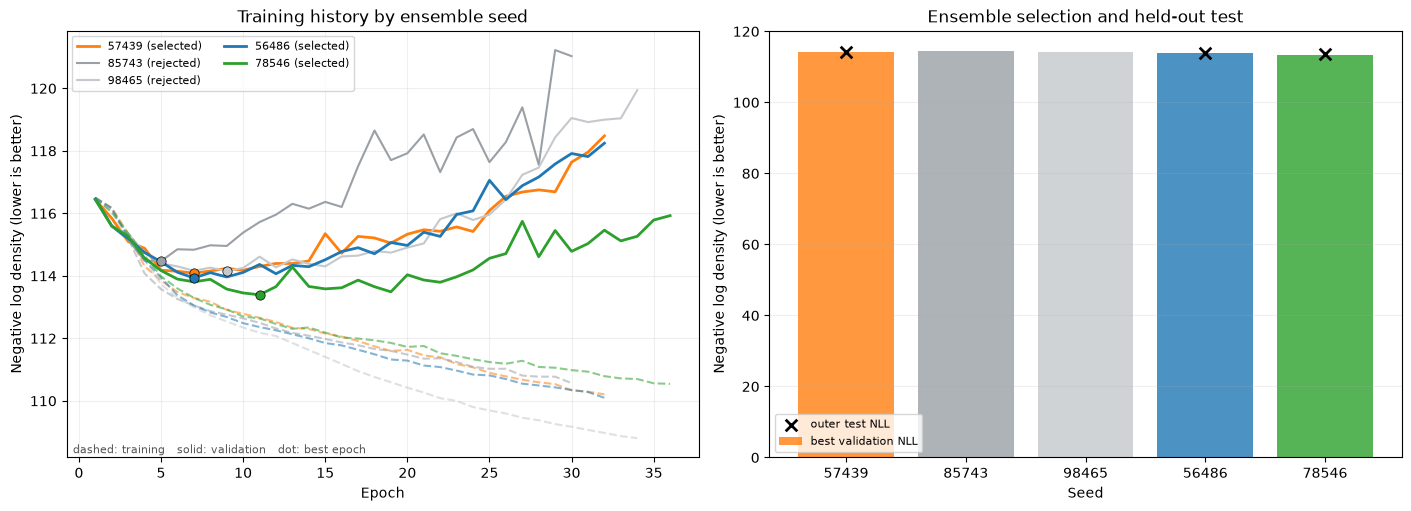

In [4]:
selected_colors = dict(zip(sorted(active_seeds), plt.cm.tab10.colors))
rejected_colors = ["#9aa0a6", "#c5c8cc"]
rejected_seeds = [seed for seed in candidate_seeds if seed not in active_seeds]
rejected_color = dict(zip(rejected_seeds, rejected_colors))

fig, (ax_curve, ax_score) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for seed in candidate_seeds:
    member = metrics[seed]
    training = member["training_loss_by_epoch"]
    validation = member["validation_loss_by_epoch"]
    epochs = range(1, len(validation) + 1)
    best_index = min(range(len(validation)), key=validation.__getitem__)
    selected = seed in active_seeds
    color = selected_colors[seed] if selected else rejected_color[seed]
    status = "selected" if selected else "rejected"

    ax_curve.plot(epochs, training, linestyle="--", color=color, alpha=0.55)
    ax_curve.plot(epochs, validation, color=color, linewidth=2 if selected else 1.5,
                  label=f"{seed} ({status})")
    ax_curve.scatter(best_index + 1, validation[best_index], color=color,
                     edgecolor="black", linewidth=0.5, s=45, zorder=3)

ax_curve.set(
    title="Training history by ensemble seed",
    xlabel="Epoch",
    ylabel="Negative log density (lower is better)",
)
ax_curve.grid(alpha=0.2)
ax_curve.legend(fontsize=8, ncol=2)
ax_curve.text(0.01, 0.01, "dashed: training   solid: validation   dot: best epoch",
              transform=ax_curve.transAxes, fontsize=8, color="#555555")

bar_colors = [selected_colors[r['seed']] if r['selected'] else rejected_color[r['seed']] for r in rows]
x_positions = range(len(rows))
ax_score.bar(x_positions, [r["best_validation_nll"] for r in rows],
             color=bar_colors, alpha=0.8, label="best validation NLL")
test_x = [i for i, row in enumerate(rows) if row["test_nll"] is not None]
test_y = [rows[i]["test_nll"] for i in test_x]
ax_score.scatter(test_x, test_y, marker="x", s=70, color="black",
                 linewidth=2, label="outer test NLL")
ax_score.set(
    title="Ensemble selection and held-out test",
    xlabel="Seed",
    ylabel="Negative log density (lower is better)",
    xticks=list(x_positions),
    xticklabels=[str(r["seed"]) for r in rows],
)
ax_score.grid(axis="y", alpha=0.2)
ax_score.legend(fontsize=8)
plt.show()

In [5]:
best_row = min(rows, key=lambda row: row["best_validation_nll"])
print("Quick interpretation")
print(
    f"- Best validation result: seed {best_row['seed']} at epoch "
    f"{best_row['best_epoch']} (NLL {best_row['best_validation_nll']:.3f})."
)
print(
    f"- Selected-ensemble mean train NLL: {summary['mean_train_negative_log_density']:.3f}; "
    f"mean test NLL: {summary['mean_test_negative_log_density']:.3f}."
)
print(
    f"- Worst selected test-minus-validation gap: "
    f"{summary['worst_test_minus_validation_negative_log_density']:.3f}."
)

for seed in candidate_seeds:
    member = metrics[seed]
    validation = member["validation_loss_by_epoch"]
    rise = validation[-1] - min(validation)
    print(f"- Seed {seed}: validation NLL ended {rise:.3f} above its minimum.")

constant_counts = {}
for seed, member in metrics.items():
    count = 0
    for warning in member.get("captured_warnings", []):
        match = re.search(r"dimension\(s\) \[(.*?)\]", warning)
        if match and match.group(1).strip():
            count += len(match.group(1).split(","))
    constant_counts[seed] = count
print(f"- Constant-feature warning counts by seed: {constant_counts}")
print("  This warning may reflect expected padding/masking, but should be checked against the input design.")

Quick interpretation
- Best validation result: seed 78546 at epoch 11 (NLL 113.394).
- Selected-ensemble mean train NLL: 112.762; mean test NLL: 113.911.
- Worst selected test-minus-validation gap: 0.112.
- Seed 57439: validation NLL ended 4.392 above its minimum.
- Seed 85743: validation NLL ended 6.559 above its minimum.
- Seed 98465: validation NLL ended 5.792 above its minimum.
- Seed 56486: validation NLL ended 4.313 above its minimum.
- Seed 78546: validation NLL ended 2.533 above its minimum.
- Constant-feature warning counts by seed: {57439: 9225, 85743: 9225, 98465: 9225, 56486: 9225, 78546: 9225}
  This warning may reflect expected padding/masking, but should be checked against the input design.


## Reproducing from another archive

Before starting Jupyter, point the notebook at another compatible project archive:

```bash
export DVCS_TRAINING_ARCHIVE=/path/to/project-after-train.tar
jupyter lab
```

The notebook is read-only with respect to the archive.

## Final holdout results

This section reads holdout summaries and PNG plots directly from completed `project-after-plot.tar` archives. It compares the same 96 training kinematics against 96 fresh, unseen kinematics without extracting either archive.

In [6]:
DEFAULT_FINAL_ARCHIVES = [
    Path(
        "/w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/results/swif2/"
        "experiment-josh-validation-same96-v22/state/"
        "experiment-josh-validation-same96-v22-project-after-plot.tar"
    ),
    Path(
        "/w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/results/swif2/"
        "experiment-josh-validation-fresh96-v23/state/"
        "experiment-josh-validation-fresh96-v23-project-after-plot.tar"
    ),
]

archive_override = os.environ.get("DVCS_FINAL_ARCHIVES")
FINAL_ARCHIVES = (
    [Path(item).expanduser() for item in archive_override.split(os.pathsep)]
    if archive_override
    else DEFAULT_FINAL_ARCHIVES
)
missing = [path for path in FINAL_ARCHIVES if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing final archive(s):\n" + "\n".join(map(str, missing)) +
        "\nSet DVCS_FINAL_ARCHIVES to colon-separated project-after-plot.tar paths."
    )

for path in FINAL_ARCHIVES:
    print(f"Final archive: {path}")

Final archive: /w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/results/swif2/experiment-josh-validation-same96-v22/state/experiment-josh-validation-same96-v22-project-after-plot.tar
Final archive: /w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/results/swif2/experiment-josh-validation-fresh96-v23/state/experiment-josh-validation-fresh96-v23-project-after-plot.tar


In [ ]:
final_results = []
for archive in FINAL_ARCHIVES:
    with tarfile.open(archive, mode="r:*") as tar:
        summary_members = [
            member.name
            for member in tar.getmembers()
            if re.search(r"/holdouts/[^/]+/summary\.json$", member.name)
        ]
        if len(summary_members) != 1:
            raise RuntimeError(
                f"Expected one final holdout summary in {archive}; "
                f"found {len(summary_members)}"
            )
        holdout_summary = read_json_member(tar, summary_members[0])
        archive_members = {member.name for member in tar.getmembers()}
        plot_images = {}
        for model, model_result in holdout_summary["models"].items():
            plot_images[model] = {}
            for quantity, container_path in model_result["plots"].items():
                member_name = str(container_path).removeprefix("/workspace/")
                if member_name not in archive_members:
                    raise FileNotFoundError(f"Missing plot {container_path} in {archive}")
                handle = tar.extractfile(member_name)
                plot_images[model][quantity] = plt.imread(
                    io.BytesIO(handle.read()), format="png"
                )

    final_results.append({
        "archive": archive,
        "summary": holdout_summary,
        "plots": plot_images,
    })

coverage_table = [
    "| Design | Model | Observable 90% | CFF 90% | GPD 90% | Invalid |",
    "|---|---|---:|---:|---:|---:|",
]
for result in final_results:
    summary_member = result["summary"]
    design = summary_member["holdout_design"]["design_name"]
    for model, model_result in summary_member["models"].items():
        coverage_table.append(
            f"| {design} | {model} | "
            f"{model_result['observable_comparison']['pointwise_90_truth_coverage']:.1%} | "
            f"{model_result['cff_comparison']['pointwise_90_truth_coverage']:.1%} | "
            f"{model_result['gpd_comparison']['pointwise_90_truth_coverage']:.1%} | "
            f"{model_result['exact_reevaluation']['invalid_count']} |"
        )
display(Markdown("\n".join(coverage_table)))

for result in final_results:
    summary_member = result["summary"]
    design = summary_member["holdout_design"]["design_name"]
    print(
        f"{design}: status={summary_member['status']}, "
        f"execution_passed={summary_member['execution_passed']}, "
        f"predictive_precision_passed={summary_member['predictive_precision_passed']}, "
        f"robustness_claim_enabled={summary_member['robustness_claim_enabled']}"
    )

In [ ]:
quantity_order = ["observables", "cffs", "gpds"]
DEFAULT_FINAL_PDF = Path(
    "/w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/results/visualizations/"
    "josh-holdout-same96-v22-vs-fresh96-v23.pdf"
)
FINAL_PDF = Path(os.environ.get("DVCS_FINAL_PDF", DEFAULT_FINAL_PDF)).expanduser()
FINAL_PDF.parent.mkdir(parents=True, exist_ok=True)

with PdfPages(FINAL_PDF) as pdf:
    page_count = 0
    for result in final_results:
        summary_member = result["summary"]
        design = summary_member["holdout_design"]["design_name"]
        for model in summary_member["models"]:
            for quantity in quantity_order:
                image = result["plots"][model][quantity]
                image_height, image_width = image.shape[:2]
                page_width = 16.0
                page_height = page_width * image_height / image_width
                fig, axis = plt.subplots(
                    figsize=(page_width, page_height), constrained_layout=True
                )
                axis.imshow(image, interpolation="none")
                axis.set_title(f"{design} — {model} — {quantity}", fontsize=16)
                axis.axis("off")
                pdf.savefig(fig, dpi=150, bbox_inches="tight")
                page_count += 1
                plt.show()
                plt.close(fig)

print(f"Saved {page_count}-page final plots PDF: {FINAL_PDF}")

print("Override final archives before starting Jupyter with:")
print("export DVCS_FINAL_ARCHIVES=/path/to/same-project-after-plot.tar:/path/to/fresh-project-after-plot.tar")
print("Optional PDF override: export DVCS_FINAL_PDF=/path/to/output.pdf")